## Imports

In [3]:
import Play
import mesmer
import model

import importlib
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

from scipy.stats import (
    norm,
    gamma,
    beta
)




### Updates (temp)

In [4]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);


## Load Data

In [ ]:
is_local_data = False
month_idx = 4
safe = False

In [ ]:
mean_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)
mean_mrsol_ds = model.shape_data.prune_group_ds_timespan(mean_mrsol_ds,Month_idx=month_idx).drop_vars("depth_bnds")

var_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)
var_mrsol_ds = model.shape_data.prune_group_ds_timespan(var_mrsol_ds,Month_idx=month_idx).drop_vars("depth_bnds")

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
test_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)
test_mrsol_ds = model.shape_data.prune_group_ds_timespan(test_mrsol_ds,Month_idx=month_idx).drop_vars("depth_bnds")

In [ ]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

mean_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

var_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

test_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [7]:
mean_mrsol_masked_ds, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mean_mrsol_ds)
mean_input_masked_ds = model.mask.mask_mask(mean_input_ds,chunk_mask)

var_mrsol_masked_ds , chunk_mask_var, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(var_mrsol_ds)
var_input_masked_ds = model.mask.mask_mask(var_input_ds,chunk_mask)

test_mrsol_masked_ds, chunk_mask_test, detail_mask_mean= model.mask.mask_nonpositiv_height_chunks(test_mrsol_ds)
test_input_masked_ds = model.mask.mask_mask(test_input_ds,chunk_mask)

In [8]:
#(mask != mask_2).sum()

In [9]:
mean_mrsol_stack_ds = mesmer.grid.stack_lat_lon(mean_mrsol_masked_ds)
var_mrsol_stack_ds = mesmer.grid.stack_lat_lon(var_mrsol_masked_ds)
test_mrsol_stack_ds = mesmer.grid.stack_lat_lon(test_mrsol_masked_ds)
mean_input_stack_ds = mesmer.grid.stack_lat_lon(mean_input_masked_ds)
var_input_stack_ds = mesmer.grid.stack_lat_lon(var_input_masked_ds)
test_input_stack_ds = mesmer.grid.stack_lat_lon(test_input_masked_ds)

### Transform Data

In [10]:
mean_mrsol_t = model.transform.none_Transform_ds(mean_mrsol_stack_ds)
var_mrsol_t = model.transform.none_Transform_ds(var_mrsol_stack_ds)
test_mrsol_t = model.transform.none_Transform_ds(test_mrsol_stack_ds)

### Linaer Regression of the mean

In [11]:
mean_predictors = mean_input_stack_ds
mean_target_da = mean_mrsol_t.mrsol

In [12]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [13]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [14]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [15]:
var_predictors = var_input_stack_ds
var_target_ds = var_mrsol_t

In [16]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [17]:
residuals_t

<xarray.Dataset> Size: 3MB
Dimensions:    (depth: 5, time: 165, gridcell: 378)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    lat        (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon        (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 2MB 0.002581 0.6862 ... 2.711e-19

### Linear Regression of the Variance

In [18]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [19]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [20]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7fb26ccdb8c0>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7fb26cc2d950>)

### Example Emulation

In [21]:
test_predictors = test_input_stack_ds
test_target_ds = test_mrsol_t.isel(depth=slice(0,2))

In [22]:
mean_prediction = LinReg_mean.predict(test_predictors).isel(depth=slice(0,2))

In [23]:
var_prediction = LinReg_variance.predict(test_predictors).isel(depth=slice(0,2)).clip(min = 1e-32)

In [24]:
var_prediction_da=var_prediction.prediction.transpose("gridcell","time", "depth")
mean_prediction_da = mean_prediction.prediction.transpose("gridcell","time", "depth")
target_da_t = test_target_ds.mrsol.transpose("gridcell","time", "depth")


In [25]:
shape_prediction = mean_prediction_da**2/var_prediction_da
scale_prediction = var_prediction_da/mean_prediction_da

In [26]:
quantil_gamma = gamma.cdf(target_da_t, a=shape_prediction, scale=scale_prediction)


In [27]:
quantil_norm = norm.cdf(target_da_t, loc=mean_prediction_da, scale=np.sqrt(var_prediction_da))


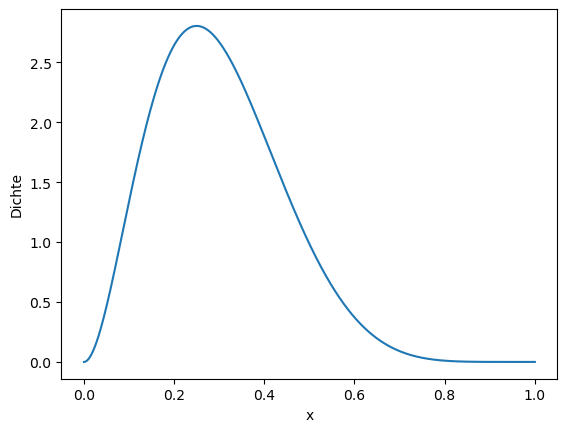

In [67]:
mue = 0.7
k = 3

x = np.linspace(0, 1, 1000)
y = beta.pdf(x, a=3,b=7)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("Dichte")
plt.show()

In [29]:
(shape_prediction.values < 15).sum()

np.int64(1539)

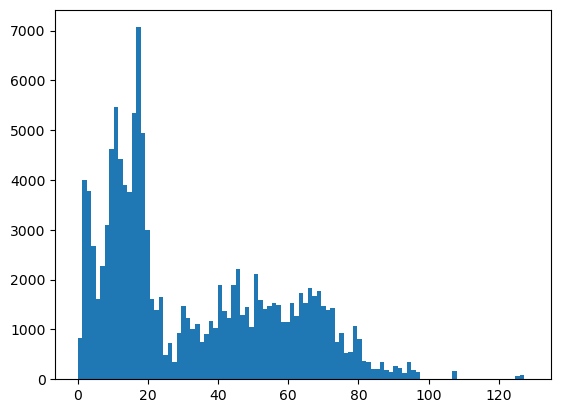

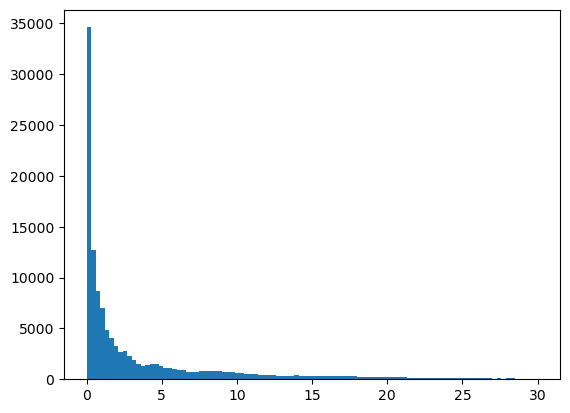

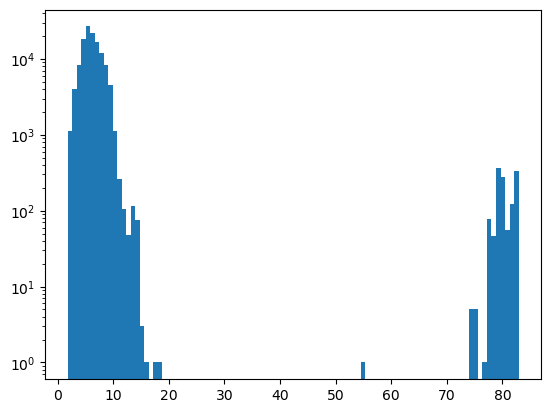

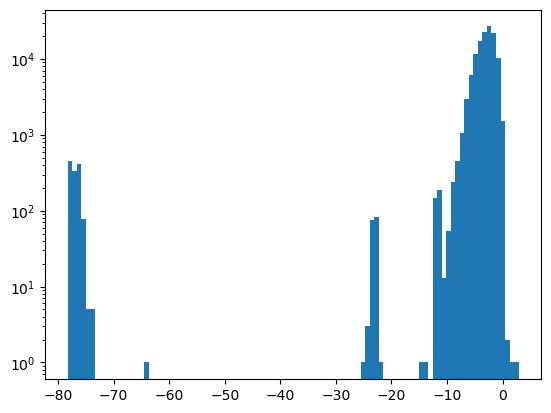

In [30]:
plt.hist(mean_prediction_da.values.reshape(-1), bins = 100)
plt.show()
plt.hist(var_prediction_da.values.reshape(-1), bins = 100,range=(0,30))
plt.show()
plt.hist(np.log(shape_prediction.values).reshape(-1), bins = 100, log = True)
plt.show()
plt.hist(np.log(scale_prediction.values).reshape(-1), bins = 100, log = True)
plt.show()

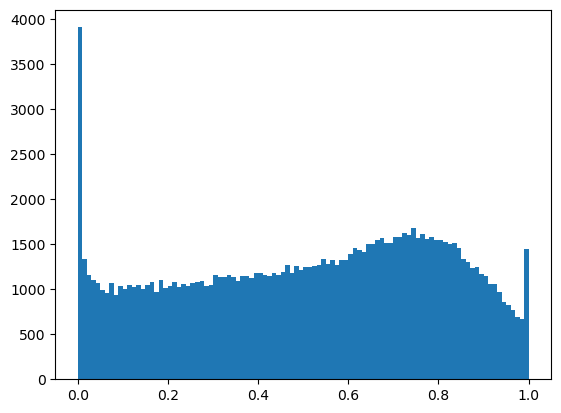

In [31]:
plt.hist(quantil_gamma.reshape(-1), bins = 100)
plt.show()

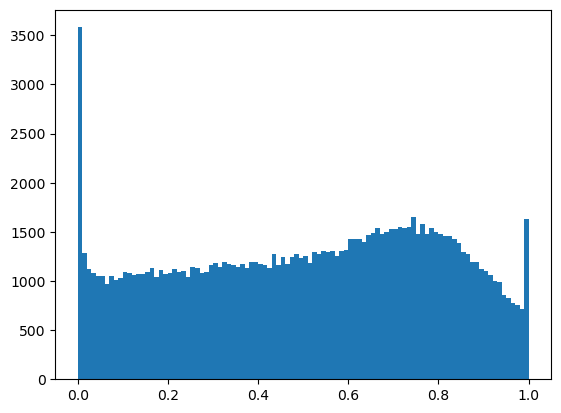

In [32]:
plt.hist(quantil_norm.reshape(-1), bins = 100)
plt.show()

In [33]:
var_prediction

<xarray.Dataset> Size: 1MB
Dimensions:     (depth: 2, gridcell: 378, time: 165)
Coordinates:
  * depth       (depth) float64 16B 0.03 0.19
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
  * time        (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    height      float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    prediction  (depth, gridcell, time) float64 998kB 0.001247 ... 2.042e-09

In [34]:
var_prediction_masked_ds = var_prediction.where(var_prediction > 1e-27)
print(var_prediction_masked_ds.to_array().isnull().sum())

mean_prediction_masked_ds = mean_prediction.where(var_prediction > 1e-27)
print(mean_prediction_masked_ds.to_array().isnull().sum())

test_target_masked_ds = test_target_ds["mrsol"].where(var_prediction.prediction > 1e-27).to_dataset()
print(test_target_masked_ds.to_array().isnull().sum())

<xarray.DataArray ()> Size: 8B
array(1291)
Coordinates:
    height   float64 8B 2.0
<xarray.DataArray ()> Size: 8B
array(1291)
Coordinates:
    height   float64 8B 2.0
<xarray.DataArray ()> Size: 8B
array(1291)
Coordinates:
    height   float64 8B 2.0


In [35]:
var_prediction_masked_da=var_prediction_masked_ds.prediction.transpose("gridcell","time", "depth")
mean_prediction_masked_da = mean_prediction_masked_ds.prediction.transpose("gridcell","time", "depth")
target_masked_da_t = test_target_masked_ds.mrsol.transpose("gridcell","time", "depth")


In [36]:

quantil_masked = norm.cdf(target_masked_da_t, loc=mean_prediction_masked_da, scale=np.sqrt(var_prediction_masked_da))


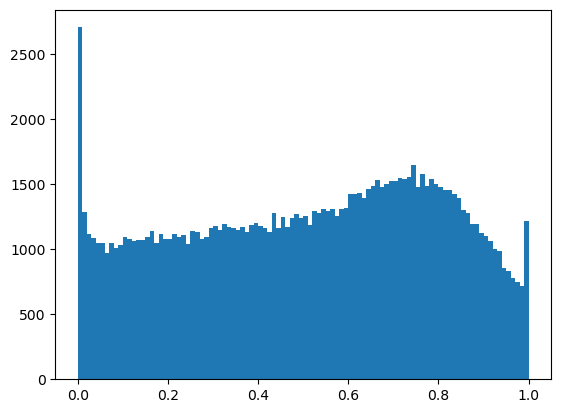

In [37]:
qdata = quantil_masked.reshape(-1)
plt.hist(qdata[np.isfinite(qdata)], bins = 100)
plt.show()

In [38]:
mean_prediction_anti_masked_ds = mean_prediction.where(var_prediction <= 1e-27)

In [39]:
test_target_anti_masked_ds = test_target_ds["mrsol"].where(var_prediction.prediction <= 1e-27).to_dataset()

In [40]:
mean_prediction_anti_masked_da =  mean_prediction_anti_masked_ds.prediction.transpose("gridcell","time", "depth")

In [41]:
test_target_anti_masked_da =  test_target_anti_masked_ds.mrsol.transpose("gridcell","time", "depth")

In [42]:
pred_data = mean_prediction_anti_masked_da.values.reshape(-1)

In [43]:
targ_data = test_target_anti_masked_da.values.reshape(-1)

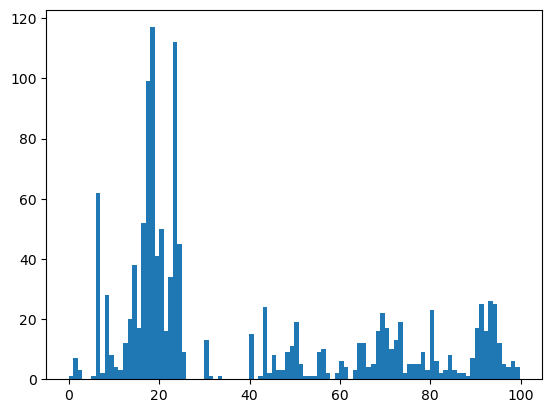

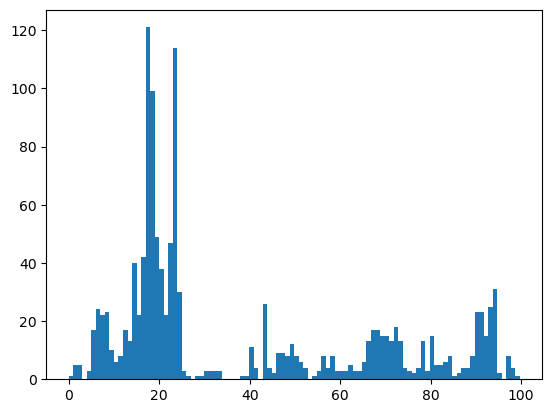

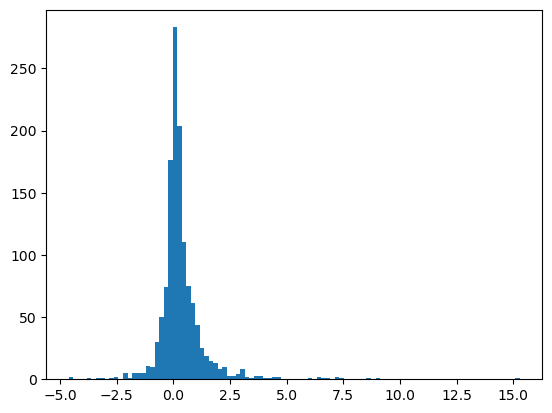

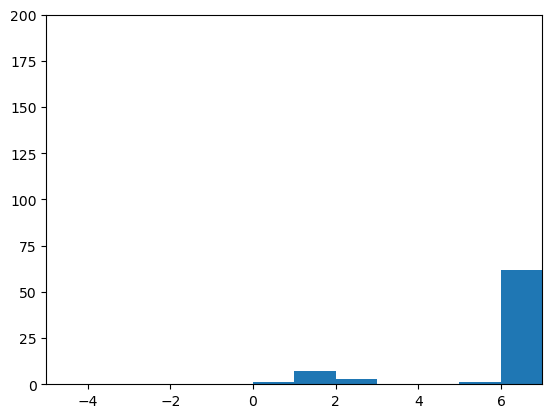

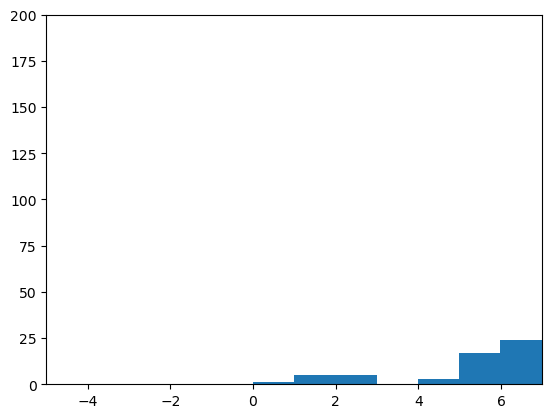

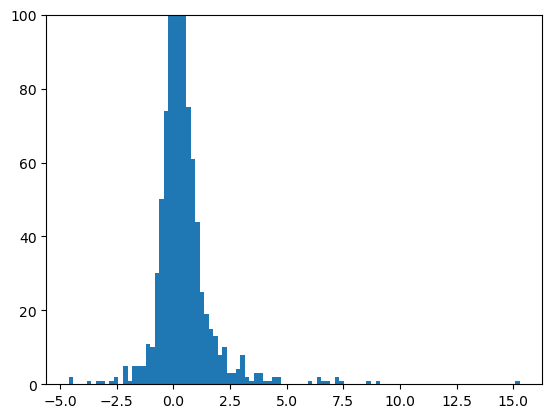

In [44]:
plt.hist(pred_data[np.isfinite(pred_data)], bins = 100)

plt.show()
plt.hist(targ_data[np.isfinite(pred_data)], bins = 100)
plt.show()
plt.hist((pred_data-targ_data)[np.isfinite(pred_data)], bins = 100)

plt.show()
plt.hist(pred_data[np.isfinite(pred_data)], bins = 100)
plt.xlim(-5,7)
plt.ylim(top=200)
plt.show()
plt.hist(targ_data[np.isfinite(pred_data)], bins = 100)
plt.xlim(-5,7)
plt.ylim(top=200)
plt.show()
mask = np.isfinite(pred_data) & ((pred_data-targ_data) != 0)
plt.hist((pred_data-targ_data)[mask], bins = 100)
plt.ylim(top=100)
plt.show()